In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

WINDOWED_DIR = Path(
    "/content/drive/MyDrive/processed_data/windowed"
)

saved_data = np.load(
    WINDOWED_DIR / "cleaned_windowed_gait_data.npz"
)

X_windows_cleaned = saved_data["X_windows"]
y_users = saved_data["y_users"]

SAMPLING_RATE = 100
WINDOW_SIZE = 500

CHANNELS = [
    "Acc-X",
    "Acc-Y",
    "Acc-Z",
    "Gyro-X",
    "Gyro-Y",
    "Gyro-Z"
]

print("Cleaned data loaded")
print("-" * 40)
print(f"X_windows_cleaned shape: {X_windows_cleaned.shape}")
print(f"y_users shape:           {y_users.shape}")
print(f"Number of users:         {len(np.unique(y_users))}")
print(f"Missing values:          {np.isnan(X_windows_cleaned).sum()}")

Cleaned data loaded
----------------------------------------
X_windows_cleaned shape: (1081, 500, 6)
y_users shape:           (1081,)
Number of users:         10
Missing values:          0


In [3]:
# Extract features from every window
from scipy.stats import skew, kurtosis

def zero_crossing_rate(signal):
    """
    Calculate how often the signal crosses its own mean.
    """
    centered_signal = signal - np.mean(signal)

    crossings = np.sum(
        centered_signal[:-1] * centered_signal[1:] < 0
    )

    return crossings / (len(signal) - 1)


def spectral_features(signal, sampling_rate):
    """
    Calculate dominant frequency, dominant magnitude,
    and spectral entropy using the FFT.
    """

    fft_values = np.fft.rfft(signal)
    frequencies = np.fft.rfftfreq(
        len(signal),
        d=1 / sampling_rate
    )

    magnitudes = np.abs(fft_values)
    power = magnitudes ** 2

    # Ignore the zero-frequency/DC component
    nonzero_frequencies = frequencies[1:]
    nonzero_magnitudes = magnitudes[1:]
    nonzero_power = power[1:]

    if len(nonzero_power) == 0 or np.sum(nonzero_power) == 0:
        dominant_frequency = 0.0
        dominant_magnitude = 0.0
        spectral_entropy = 0.0
    else:
        dominant_index = np.argmax(nonzero_power)

        dominant_frequency = (
            nonzero_frequencies[dominant_index]
        )

        dominant_magnitude = (
            nonzero_magnitudes[dominant_index]
        )

        probability_distribution = (
            nonzero_power / np.sum(nonzero_power)
        )

        spectral_entropy = -np.sum(
            probability_distribution *
            np.log2(probability_distribution + 1e-12)
        )

    return (
        dominant_frequency,
        dominant_magnitude,
        spectral_entropy
    )


def extract_channel_features(signal, sampling_rate):
    """
    Extract 20 features from one sensor channel.
    """

    mean_value = np.mean(signal)
    std_value = np.std(signal)
    variance_value = np.var(signal)

    minimum_value = np.min(signal)
    maximum_value = np.max(signal)
    range_value = maximum_value - minimum_value

    median_value = np.median(signal)
    q25_value = np.percentile(signal, 25)
    q75_value = np.percentile(signal, 75)
    iqr_value = q75_value - q25_value

    mean_absolute_deviation = np.mean(
        np.abs(signal - mean_value)
    )

    rms_value = np.sqrt(np.mean(signal ** 2))

    skewness_value = skew(signal)
    kurtosis_value = kurtosis(signal)

    crossing_rate = zero_crossing_rate(signal)

    signal_energy = np.sum(signal ** 2)

    dominant_frequency, dominant_magnitude, spectral_entropy = (
        spectral_features(signal, sampling_rate)
    )

    derivative_std = np.std(np.diff(signal))

    return {
        "mean": mean_value,
        "std": std_value,
        "variance": variance_value,
        "min": minimum_value,
        "max": maximum_value,
        "range": range_value,
        "median": median_value,
        "q25": q25_value,
        "q75": q75_value,
        "iqr": iqr_value,
        "mean_abs_deviation": mean_absolute_deviation,
        "rms": rms_value,
        "skewness": skewness_value,
        "kurtosis": kurtosis_value,
        "zero_crossing_rate": crossing_rate,
        "energy": signal_energy,
        "dominant_frequency": dominant_frequency,
        "dominant_magnitude": dominant_magnitude,
        "spectral_entropy": spectral_entropy,
        "derivative_std": derivative_std
    }


# Extract features from every window
feature_rows = []

for window in X_windows_cleaned:

    window_features = {}

    for channel_index, channel_name in enumerate(CHANNELS):

        channel_signal = window[:, channel_index]

        channel_features = extract_channel_features(
            channel_signal,
            SAMPLING_RATE
        )

        for feature_name, feature_value in channel_features.items():

            column_name = f"{channel_name}_{feature_name}"

            window_features[column_name] = feature_value

    feature_rows.append(window_features)


X_features_df = pd.DataFrame(feature_rows)

print("Feature extraction complete")
print("-" * 40)
print(f"Feature matrix shape: {X_features_df.shape}")
print(f"Number of feature columns: {len(X_features_df.columns)}")
print(f"Missing values: {X_features_df.isna().sum().sum()}")

print("\nFirst five feature columns:")
display(X_features_df.iloc[:, :5].head())

print("\nFeature names:")
print(X_features_df.columns.tolist())

Feature extraction complete
----------------------------------------
Feature matrix shape: (1081, 120)
Number of feature columns: 120
Missing values: 0

First five feature columns:


,Acc-X_mean,Acc-X_std,Acc-X_variance,Acc-X_min,Acc-X_max
0,1.168585,2.094110,4.385299,-4.992198,6.416003
1,1.627328,1.870048,3.497081,-4.992198,6.416003
2,1.429254,2.150311,4.623837,-5.801383,6.634718
3,1.011592,2.569682,6.603266,-6.274056,9.748882
4,1.033654,2.765729,7.649257,-6.274056,9.748882



Feature names:
['Acc-X_mean', 'Acc-X_std', 'Acc-X_variance', 'Acc-X_min', 'Acc-X_max', 'Acc-X_range', 'Acc-X_median', 'Acc-X_q25', 'Acc-X_q75', 'Acc-X_iqr', 'Acc-X_mean_abs_deviation', 'Acc-X_rms', 'Acc-X_skewness', 'Acc-X_kurtosis', 'Acc-X_zero_crossing_rate', 'Acc-X_energy', 'Acc-X_dominant_frequency', 'Acc-X_dominant_magnitude', 'Acc-X_spectral_entropy', 'Acc-X_derivative_std', 'Acc-Y_mean', 'Acc-Y_std', 'Acc-Y_variance', 'Acc-Y_min', 'Acc-Y_max', 'Acc-Y_range', 'Acc-Y_median', 'Acc-Y_q25', 'Acc-Y_q75', 'Acc-Y_iqr', 'Acc-Y_mean_abs_deviation', 'Acc-Y_rms', 'Acc-Y_skewness', 'Acc-Y_kurtosis', 'Acc-Y_zero_crossing_rate', 'Acc-Y_energy', 'Acc-Y_dominant_frequency', 'Acc-Y_dominant_magnitude', 'Acc-Y_spectral_entropy', 'Acc-Y_derivative_std', 'Acc-Z_mean', 'Acc-Z_std', 'Acc-Z_variance', 'Acc-Z_min', 'Acc-Z_max', 'Acc-Z_range', 'Acc-Z_median', 'Acc-Z_q25', 'Acc-Z_q75', 'Acc-Z_iqr', 'Acc-Z_mean_abs_deviation', 'Acc-Z_rms', 'Acc-Z_skewness', 'Acc-Z_kurtosis', 'Acc-Z_zero_crossing_rate', '

In [5]:
# Select the best 10 features
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

# Encode user labels as integers from 0 to 9
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_users)

# Confirm that all feature values are finite
print("All feature values finite:",
      np.isfinite(X_features_df.to_numpy()).all())

# Create and fit the feature selector
feature_selector = SelectKBest(
    score_func=f_classif,
    k=10
)

feature_selector.fit(
    X_features_df,
    y_encoded
)

# Extract scores for every feature
feature_scores = pd.DataFrame({
    "Feature": X_features_df.columns,
    "ANOVA F-score": feature_selector.scores_,
    "p-value": feature_selector.pvalues_
})

# Sort all features by score
feature_scores = feature_scores.sort_values(
    by="ANOVA F-score",
    ascending=False
).reset_index(drop=True)

# Get the selected feature names
selected_feature_names = (
    feature_scores
    .head(10)["Feature"]
    .tolist()
)

# Transform the complete feature matrix to the selected 10 features
X_selected = feature_selector.transform(
    X_features_df
)

print("Feature selection complete")
print("-" * 40)
print(f"Original feature shape: {X_features_df.shape}")
print(f"Selected feature shape: {X_selected.shape}")

print("\nSelected features:")
display(feature_scores.head(10))

print("\nSelected feature names:")
for rank, feature_name in enumerate(
    selected_feature_names,
    start=1
):
    print(f"{rank}. {feature_name}")

All feature values finite: True
Feature selection complete
----------------------------------------
Original feature shape: (1081, 120)
Selected feature shape: (1081, 10)

Selected features:


,Feature,ANOVA F-score,p-value
0,Acc-Y_mean,3758.364427,0.000000e+00
1,Acc-Y_median,3687.888262,0.000000e+00
2,Acc-Y_q75,3188.135258,0.000000e+00
3,Acc-Y_q25,2976.460655,0.000000e+00
4,Acc-Y_max,1428.680035,0.000000e+00
5,Acc-Y_min,896.149442,0.000000e+00
6,Acc-Z_mean,484.339871,0.000000e+00
7,Acc-Z_skewness,427.293850,0.000000e+00
8,Acc-Z_q75,351.703684,1.771764e-312
9,Gyro-Y_variance,304.441549,6.287449e-288



Selected feature names:
1. Acc-Y_mean
2. Acc-Y_median
3. Acc-Y_q75
4. Acc-Y_q25
5. Acc-Y_max
6. Acc-Y_min
7. Acc-Z_mean
8. Acc-Z_skewness
9. Acc-Z_q75
10. Gyro-Y_variance


In [6]:
# Scale the selected features
from sklearn.preprocessing import StandardScaler

# Scale the selected 10 features
feature_scaler = StandardScaler()

X_selected_scaled = feature_scaler.fit_transform(
    X_selected
)

print("Feature scaling complete")
print("-" * 40)
print(f"Scaled feature shape: {X_selected_scaled.shape}")
print(f"Scaled minimum: {X_selected_scaled.min():.4f}")
print(f"Scaled maximum: {X_selected_scaled.max():.4f}")

# Inspect the resulting feature statistics
scaled_feature_summary = pd.DataFrame(
    X_selected_scaled,
    columns=selected_feature_names
).agg(["mean", "std"]).T

display(scaled_feature_summary)

Feature scaling complete
----------------------------------------
Scaled feature shape: (1081, 10)
Scaled minimum: -3.1724
Scaled maximum: 7.8840


,mean,std
Acc-Y_mean,-1.051682e-16,1.000463
Acc-Y_median,-7.887616e-17,1.000463
Acc-Y_q75,0.000000e+00,1.000463
Acc-Y_q25,0.000000e+00,1.000463
Acc-Y_max,0.000000e+00,1.000463
Acc-Y_min,0.000000e+00,1.000463
Acc-Z_mean,7.887616e-17,1.000463
Acc-Z_skewness,-5.258411e-17,1.000463
Acc-Z_q75,0.000000e+00,1.000463
Gyro-Y_variance,-5.258411e-17,1.000463


In [7]:
# Define and Inspect the FNN
import tensorflow as tf

# Make results more reproducible
np.random.seed(42)
tf.random.set_seed(42)


def build_fnn_model(input_features, number_of_classes):
    """
    Build the FNN for 10-class user identification.
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_features,)),

        tf.keras.layers.Dense(
            5,
            activation="relu",
            name="hidden_layer_1"
        ),

        tf.keras.layers.Dense(
            5,
            activation="relu",
            name="hidden_layer_2"
        ),

        tf.keras.layers.Dense(
            number_of_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


fnn_model = build_fnn_model(
    input_features=X_selected_scaled.shape[1],
    number_of_classes=len(np.unique(y_encoded))
)

fnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the FNN with 5 fold cross validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

N_SPLITS = 5
EPOCHS = 40
BATCH_SIZE = 32

number_of_classes = len(np.unique(y_encoded))

cross_validator = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

fold_metrics = []
training_histories = []

all_true_labels = []
all_predicted_labels = []

for fold_number, (train_indices, validation_indices) in enumerate(
    cross_validator.split(X_features_df, y_encoded),
    start=1
):
    print(f"Training fold {fold_number}/{N_SPLITS}...")

    # Split the original 120-feature matrix
    X_train_raw = X_features_df.iloc[train_indices]
    X_validation_raw = X_features_df.iloc[validation_indices]

    y_train = y_encoded[train_indices]
    y_validation = y_encoded[validation_indices]

    # Fit feature selection only on the training fold
    fold_selector = SelectKBest(
        score_func=f_classif,
        k=10
    )

    X_train_selected = fold_selector.fit_transform(
        X_train_raw,
        y_train
    )

    X_validation_selected = fold_selector.transform(
        X_validation_raw
    )

    # Fit scaling only on the training fold
    fold_scaler = StandardScaler()

    X_train_scaled = fold_scaler.fit_transform(
        X_train_selected
    )

    X_validation_scaled = fold_scaler.transform(
        X_validation_selected
    )

    # Create a completely new model for this fold
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42 + fold_number)

    fold_model = build_fnn_model(
        input_features=10,
        number_of_classes=number_of_classes
    )

    fold_history = fold_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_validation_scaled,
            y_validation
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_histories.append(fold_history.history)

    # Predict validation samples
    validation_probabilities = fold_model.predict(
        X_validation_scaled,
        verbose=0
    )

    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1
    )

    all_true_labels.extend(y_validation)
    all_predicted_labels.extend(validation_predictions)

    fold_accuracy = accuracy_score(
        y_validation,
        validation_predictions
    )

    fold_precision = precision_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    fold_recall = recall_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    fold_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    fold_metrics.append({
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Macro Precision": fold_precision,
        "Macro Recall": fold_recall,
        "Macro F1": fold_f1
    })

    print(
        f"  Accuracy: {fold_accuracy:.4f} | "
        f"Macro F1: {fold_f1:.4f}"
    )


# Convert validation results to arrays
all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)

fold_metrics_df = pd.DataFrame(fold_metrics)

print("\nFold-level results:")
display(fold_metrics_df)

print("\nAverage cross-validation results:")
display(
    fold_metrics_df.drop(columns="Fold")
    .agg(["mean", "std"])
)

print("\nOverall classification report:")
print(
    classification_report(
        all_true_labels,
        all_predicted_labels,
        labels=np.arange(number_of_classes),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Training fold 1/5...
  Accuracy: 0.6912 | Macro F1: 0.6056
Training fold 2/5...
  Accuracy: 0.6713 | Macro F1: 0.5946
Training fold 3/5...


  Accuracy: 0.7778 | Macro F1: 0.7257
Training fold 4/5...


  Accuracy: 0.6898 | Macro F1: 0.6157
Training fold 5/5...
  Accuracy: 0.6759 | Macro F1: 0.5923

Fold-level results:


,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,0.691244,0.775941,0.649448,0.605555
1,2,0.671296,0.619398,0.639262,0.594566
2,3,0.777778,0.785449,0.753271,0.725744
3,4,0.689815,0.617282,0.669930,0.615695
4,5,0.675926,0.642060,0.644721,0.592321



Average cross-validation results:


,Accuracy,Macro Precision,Macro Recall,Macro F1
mean,0.701212,0.688026,0.671326,0.626776
std,0.043663,0.085217,0.047253,0.056108



Overall classification report:
              precision    recall  f1-score   support

         112       0.56      0.52      0.54       101
          13       0.58      0.83      0.68       117
           2       0.76      0.94      0.84       136
          23       0.66      0.98      0.79       132
          24       0.60      0.32      0.42        90
          49       0.81      0.51      0.63       101
          52       0.51      0.26      0.35        95
          55       0.94      1.00      0.97       117
          70       0.63      0.62      0.63       108
          78       1.00      0.73      0.84        84

    accuracy                           0.70      1081
   macro avg       0.70      0.67      0.67      1081
weighted avg       0.70      0.70      0.68      1081



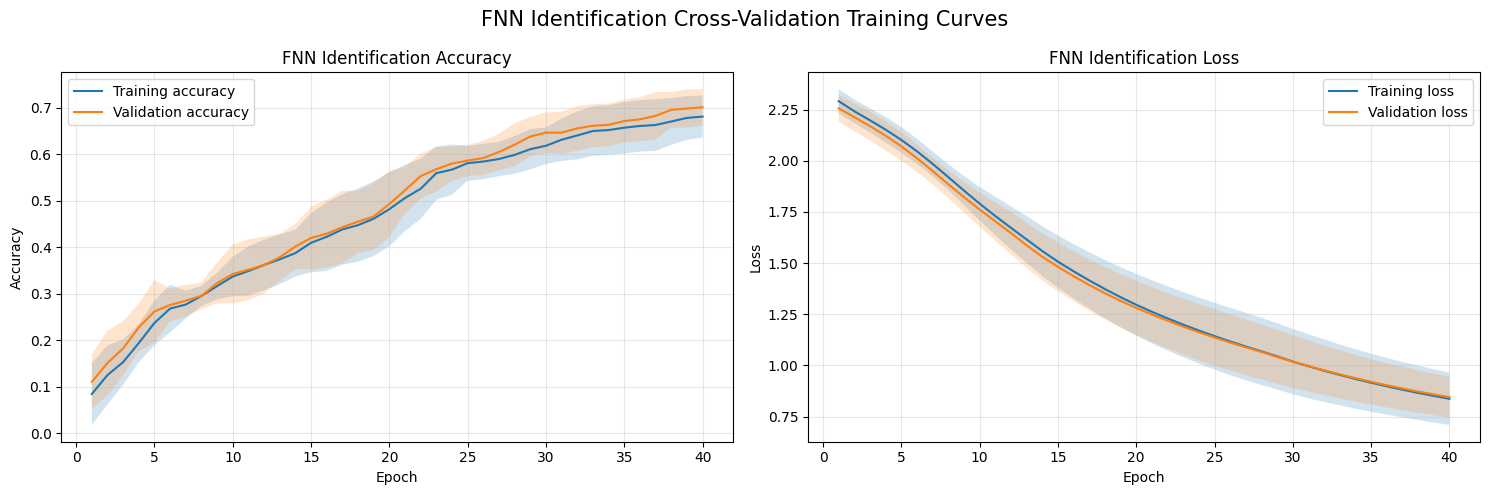

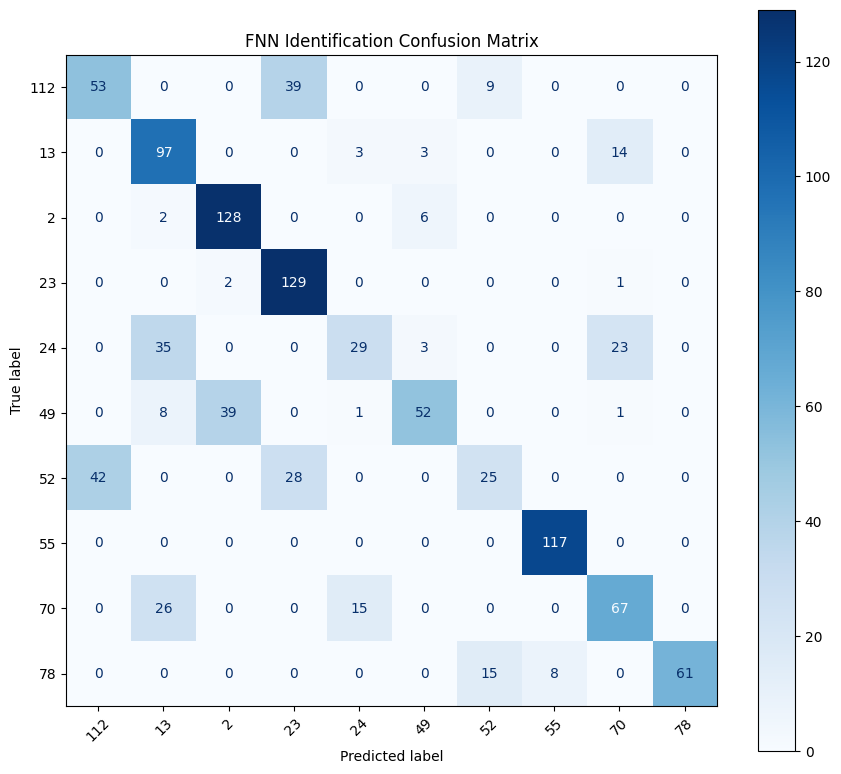

Saved plots to:
/content/drive/MyDrive/processed_data/plots


In [9]:
# Generate evaluation plots
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Convert training histories into arrays
train_accuracy = np.array([
    history["accuracy"]
    for history in training_histories
])

validation_accuracy = np.array([
    history["val_accuracy"]
    for history in training_histories
])

train_loss = np.array([
    history["loss"]
    for history in training_histories
])

validation_loss = np.array([
    history["val_loss"]
    for history in training_histories
])

epochs = np.arange(1, train_accuracy.shape[1] + 1)

# Calculate mean and standard deviation across folds
mean_train_accuracy = train_accuracy.mean(axis=0)
std_train_accuracy = train_accuracy.std(axis=0)

mean_validation_accuracy = validation_accuracy.mean(axis=0)
std_validation_accuracy = validation_accuracy.std(axis=0)

mean_train_loss = train_loss.mean(axis=0)
std_train_loss = train_loss.std(axis=0)

mean_validation_loss = validation_loss.mean(axis=0)
std_validation_loss = validation_loss.std(axis=0)


# Create output directory for plots
PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# Plot average training and validation curves
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5)
)

# Accuracy plot
axes[0].plot(
    epochs,
    mean_train_accuracy,
    label="Training accuracy"
)

axes[0].fill_between(
    epochs,
    mean_train_accuracy - std_train_accuracy,
    mean_train_accuracy + std_train_accuracy,
    alpha=0.2
)

axes[0].plot(
    epochs,
    mean_validation_accuracy,
    label="Validation accuracy"
)

axes[0].fill_between(
    epochs,
    mean_validation_accuracy - std_validation_accuracy,
    mean_validation_accuracy + std_validation_accuracy,
    alpha=0.2
)

axes[0].set_title("FNN Identification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Loss plot
axes[1].plot(
    epochs,
    mean_train_loss,
    label="Training loss"
)

axes[1].fill_between(
    epochs,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    alpha=0.2
)

axes[1].plot(
    epochs,
    mean_validation_loss,
    label="Validation loss"
)

axes[1].fill_between(
    epochs,
    mean_validation_loss - std_validation_loss,
    mean_validation_loss + std_validation_loss,
    alpha=0.2
)

axes[1].set_title("FNN Identification Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    "FNN Identification Cross-Validation Training Curves",
    fontsize=15
)

plt.tight_layout()

accuracy_loss_path = PLOTS_DIR / "fnn_identification_training_curves.png"
plt.savefig(accuracy_loss_path, dpi=200, bbox_inches="tight")
plt.show()


# Create confusion matrix
confusion_matrix_values = confusion_matrix(
    all_true_labels,
    all_predicted_labels,
    labels=np.arange(number_of_classes)
)

fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=label_encoder.classes_
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

ax.set_title("FNN Identification Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = PLOTS_DIR / "fnn_identification_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved plots to:")
print(PLOTS_DIR)

In [10]:
# Save FNN results
RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save fold-level metrics
fold_metrics_df.to_csv(
    RESULTS_DIR / "fnn_identification_fold_metrics.csv",
    index=False
)

# Create and save the detailed classification report
classification_report_dict = classification_report(
    all_true_labels,
    all_predicted_labels,
    labels=np.arange(number_of_classes),
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

classification_report_df.to_csv(
    RESULTS_DIR / "fnn_identification_classification_report.csv"
)

# Save the confusion matrix
confusion_matrix_df = pd.DataFrame(
    confusion_matrix_values,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

confusion_matrix_df.to_csv(
    RESULTS_DIR / "fnn_identification_confusion_matrix.csv"
)

# Save the selected feature names
pd.DataFrame({
    "Selected feature": selected_feature_names
}).to_csv(
    RESULTS_DIR / "fnn_selected_features.csv",
    index=False
)

print("FNN identification results saved to:")
print(RESULTS_DIR)

FNN identification results saved to:
/content/drive/MyDrive/processed_data/results
